In [76]:
import pandas as pd
import numpy as np

In [77]:
df = pd.read_csv('../raw_data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# A) Compare Sample

In [78]:

dfs = df.sample(25,random_state=2)
dfs.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
158,2,88,74,19,53,29.0,0.229,22,0
251,2,129,84,0,0,28.0,0.284,27,0
631,0,102,78,40,90,34.5,0.238,24,0
757,0,123,72,0,0,36.3,0.258,52,1
689,1,144,82,46,180,46.1,0.335,46,1


<Axes: title={'center': 'Glucose Sample vs Pop'}, xlabel='index'>

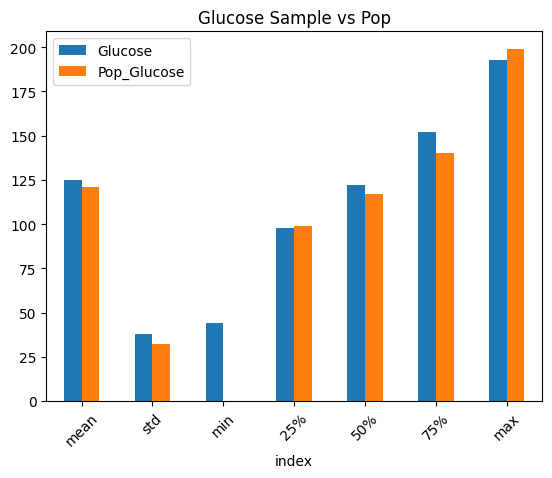

In [79]:
sample = dfs['Glucose'].describe().reset_index()
pop = df['Glucose'].describe().reset_index()

sample['Pop_Glucose'] = pop['Glucose'] 
sample.set_index('index').drop(index='count').plot.bar(rot=45, title='Glucose Sample vs Pop')

In [80]:
sample

,index,Glucose,Pop_Glucose
0,count,25.000,768.000000
1,mean,124.800,120.894531
2,std,38.139,31.972618
3,min,44.000,0.000000
4,25%,98.000,99.000000
5,50%,122.000,117.000000
6,75%,152.000,140.250000
7,max,193.000,199.000000


# B) Compare BMI

47.972 47.52599999999996


<Axes: title={'center': 'BMI 98th percentile'}, xlabel='Group'>

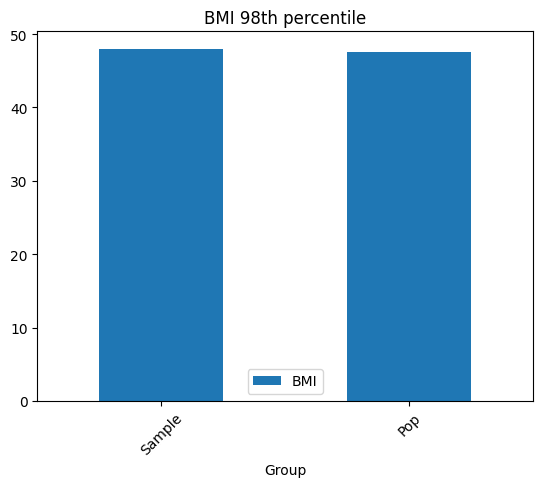

In [81]:
sample = dfs['BMI'].quantile(0.98)
pop = df['BMI'].quantile(0.98)

print(sample, pop)

pd.DataFrame({
    'Group': ['Sample', 'Pop'],
    'BMI': [sample, pop]
}).set_index('Group').plot.bar(rot=45, title='BMI 98th percentile')

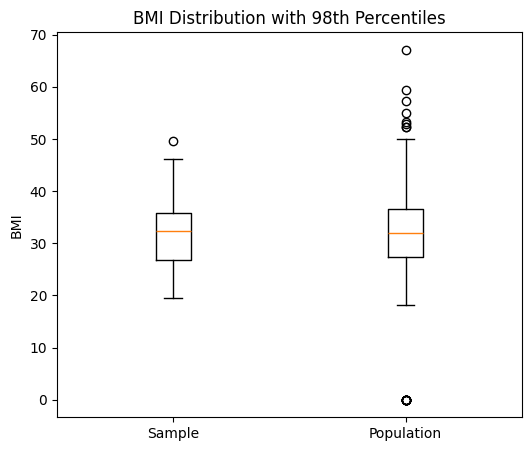

In [82]:
import matplotlib.pyplot as plt

ax = plt.figure(figsize=(6,5)).gca()

ax.boxplot([dfs['BMI'], df['BMI']], tick_labels=['Sample', 'Population'])

plt.ylabel("BMI")
plt.title("BMI Distribution with 98th Percentiles")
plt.show()

# C) Bootstrap

In [83]:
pd.concat([df['BloodPressure'].sample(150, replace=True, random_state=0).describe(), df['BloodPressure'].sample(150, replace=True, random_state=1).describe()]).reset_index().set_index('index').groupby(by='index').mean()

,BloodPressure
index,
25%,62.125000
50%,72.000000
75%,80.750000
count,150.000000
max,110.000000
mean,69.116667
min,0.000000
std,19.204334


In [84]:
n=500
samples = []
for i in range(n):
    bp = df['BloodPressure'].sample(150, replace=True, random_state=i)
    samples.append(bp.describe())

sample_stats = pd.concat(samples).reset_index().set_index('index').groupby(by='index').mean()
sample_stats

,BloodPressure
index,
25%,63.012500
50%,71.485000
75%,79.512000
count,150.000000
max,110.748000
mean,69.171987
min,0.000000
std,19.202760


In [85]:
pop_stats = df['BloodPressure'].describe()

sample_stats['Pop_BloodPressure'] = pop_stats
sample_stats

,BloodPressure,Pop_BloodPressure
index,,
25%,63.012500,62.000000
50%,71.485000,72.000000
75%,79.512000,80.000000
count,150.000000,768.000000
max,110.748000,122.000000
mean,69.171987,69.105469
min,0.000000,0.000000
std,19.202760,19.355807


<Axes: title={'center': 'Blood Pressure Bootstrap vs Pop'}, xlabel='index'>

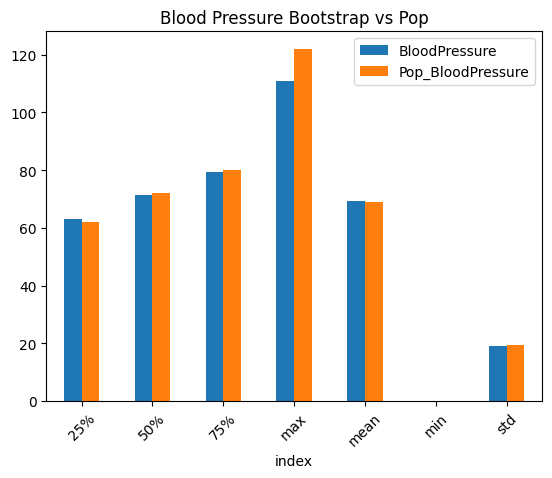

In [86]:
sample_stats.drop(index='count').plot.bar(rot=45, title='Blood Pressure Bootstrap vs Pop')